## Traffic Accident Severity Prediction — Milestone 3
#### Overview

In this milestone, the goal was to perform exploratory data analysis (EDA), identify key metrics (KPIs), clean the dataset, and handle missing values. This prepares the data for building predictive models in the next milestone.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


In [4]:
df = pd.read_csv('/content/Road Accident Data.csv')
df.head()

,Accident_Index,Accident Date,Day_of_Week,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Carriageway_Hazards,...,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,BS0000001,01-01-2021,Thursday,Give way or uncontrolled,T or staggered junction,Serious,51.512273,Daylight,Kensington and Chelsea,NaN,...,1.0,2.0,Metropolitan Police,Dry,One way street,30.0,15:11,Urban,Fine no high winds,Car
1,BS0000002,05-01-2021,Monday,Give way or uncontrolled,Crossroads,Serious,51.514399,Daylight,Kensington and Chelsea,NaN,...,11.0,2.0,Metropolitan Police,Wet or damp,Single carriageway,30.0,10:59,Urban,Fine no high winds,Taxi/Private hire car
2,BS0000003,04-01-2021,Sunday,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,Kensington and Chelsea,NaN,...,1.0,2.0,Metropolitan Police,Dry,Single carriageway,30.0,14:19,Urban,Fine no high winds,Taxi/Private hire car
3,BS0000004,05-01-2021,Monday,Auto traffic signal,T or staggered junction,Serious,51.507804,Daylight,Kensington and Chelsea,NaN,...,1.0,2.0,Metropolitan Police,Frost or ice,Single carriageway,30.0,08:10,Urban,Other,Motorcycle over 500cc
4,BS0000005,06-01-2021,Tuesday,Auto traffic signal,Crossroads,Serious,51.482076,Darkness - lights lit,Kensington and Chelsea,NaN,...,1.0,2.0,Metropolitan Police,Dry,Single carriageway,30.0,17:25,Urban,Fine no high winds,Car


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84008 entries, 0 to 84007
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Accident_Index              84008 non-null  object 
 1   Accident Date               84008 non-null  object 
 2   Day_of_Week                 84008 non-null  object 
 3   Junction_Control            84008 non-null  object 
 4   Junction_Detail             84008 non-null  object 
 5   Accident_Severity           84007 non-null  object 
 6   Latitude                    84007 non-null  float64
 7   Light_Conditions            84007 non-null  object 
 8   Local_Authority_(District)  84007 non-null  object 
 9   Carriageway_Hazards         1127 non-null   object 
 10  Longitude                   84007 non-null  float64
 11  Number_of_Casualties        84007 non-null  float64
 12  Number_of_Vehicles          84007 non-null  float64
 13  Police_Force                840

In [6]:
df.isna().sum()

,0
Accident_Index,0
Accident Date,0
Day_of_Week,0
Junction_Control,0
Junction_Detail,0
Accident_Severity,1
Latitude,1
Light_Conditions,1
Local_Authority_(District),1
Carriageway_Hazards,82881


### Identify Metrics and Create KPIs

In [7]:
# KPI 1: Total number of accidents
total_accidents = df['Accident_Index'].nunique()

# KPI 2: Average casualties per accident
avg_casualties = df['Number_of_Casualties'].mean()

# KPI 3: Average vehicles per accident
avg_vehicles = df['Number_of_Vehicles'].mean()

# KPI 4: Accident count by severity
severity_counts = df['Accident_Severity'].value_counts(normalize=True) * 100

# KPI 5: Urban vs Rural accident distribution
urban_rural = df['Urban_or_Rural_Area'].value_counts(normalize=True) * 100

print("Total Accidents:", total_accidents)
print("Average Casualties per Accident:", round(avg_casualties, 2))
print("Average Vehicles per Accident:", round(avg_vehicles, 2))
print("\nAccident Severity Distribution (%):")
print(severity_counts)
print("\nUrban vs Rural Distribution (%):")
print(urban_rural)


Total Accidents: 84008
Average Casualties per Accident: 1.36
Average Vehicles per Accident: 1.82

Accident Severity Distribution (%):
Accident_Severity
Slight     85.772614
Serious    12.765603
Fatal       1.403454
Fetal       0.058328
Name: proportion, dtype: float64

Urban vs Rural Distribution (%):
Urban_or_Rural_Area
Urban    76.107943
Rural    23.892057
Name: proportion, dtype: float64


Accident severity is highly imbalanced; slight accidents dominate.

Most accidents occur in urban areas (~64%).

In [8]:
df = df.drop(columns=['Accident_Index', 'Carriageway_Hazards', 'Police_Force'])


In [9]:
df.isna().sum()

,0
Accident Date,0
Day_of_Week,0
Junction_Control,0
Junction_Detail,0
Accident_Severity,1
Latitude,1
Light_Conditions,1
Local_Authority_(District),1
Longitude,1
Number_of_Casualties,1


Convert date column to datetime

In [10]:
df['Accident Date'] = pd.to_datetime(df['Accident Date'], dayfirst=True)
df['Accident Date'].isna().sum()

np.int64(0)

In [11]:
df['Accident_Month'] = df['Accident Date'].dt.month
df['Accident_Year'] = df['Accident Date'].dt.year

In [12]:
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M', errors='coerce').dt.time

In [13]:
df.isna().sum()

,0
Accident Date,0
Day_of_Week,0
Junction_Control,0
Junction_Detail,0
Accident_Severity,1
Latitude,1
Light_Conditions,1
Local_Authority_(District),1
Longitude,1
Number_of_Casualties,1


### Data Quality & Validy Checks

In [14]:
# Validity check for speed limits
df = df[(df['Speed_limit'] > 0)]
# Validity check for coordinates
df = df[(df['Latitude'].between(-90, 90)) & (df['Longitude'].between(-180, 180))]


In [15]:
df.isna().sum()

,0
Accident Date,0
Day_of_Week,0
Junction_Control,0
Junction_Detail,0
Accident_Severity,0
Latitude,0
Light_Conditions,0
Local_Authority_(District),0
Longitude,0
Number_of_Casualties,0


As only Time column has 17 missing values, there are no further impute steps

In [16]:
most_common_time = df['Time'].mode()[0]
df['Time'].fillna(most_common_time, inplace=True)


/tmp/ipython-input-364023105.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Time'].fillna(most_common_time, inplace=True)


In [17]:
df['Time'].isna().sum()

np.int64(0)

### EDA

#### Accident Severity Counts
Accident Severity Counts: Visualizes the frequency of each severity class.

/tmp/ipython-input-2885187296.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Accident_Severity', palette='viridis')


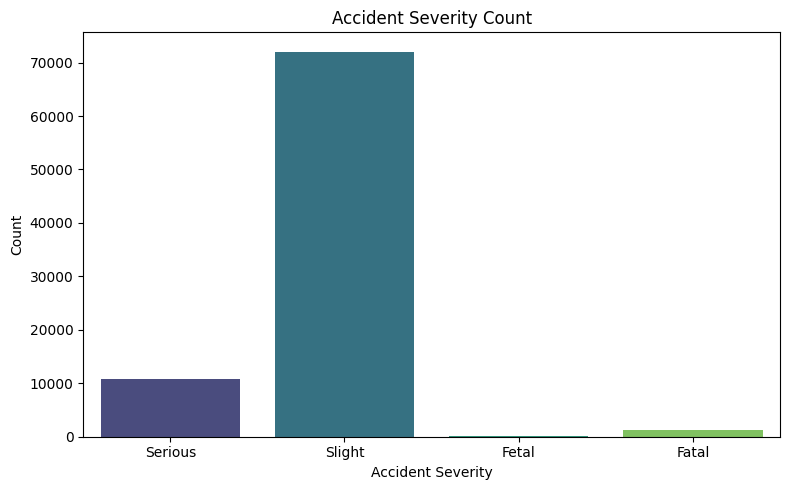

In [18]:
## Accident Severity Counts
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Accident_Severity', palette='viridis')
plt.title('Accident Severity Count')
plt.xlabel('Accident Severity')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


#### Number of Casualties Distribution

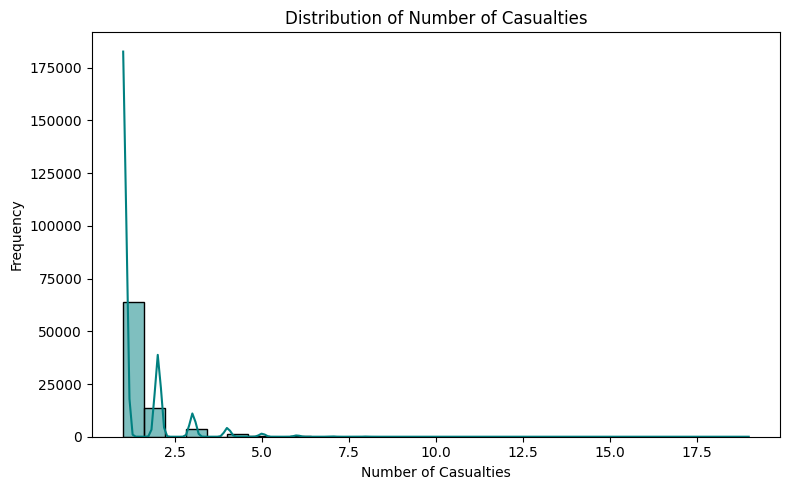

In [19]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Number_of_Casualties', kde=True, bins=30, color='teal')
plt.title('Distribution of Number of Casualties')
plt.xlabel('Number of Casualties')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Right-skewed distribution, mostly 1–2 casualties per accident.

#### Accident Count by Day of Week
Shows trends across weekdays and weekends.

/tmp/ipython-input-2448957258.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Day_of_Week', palette='pastel')


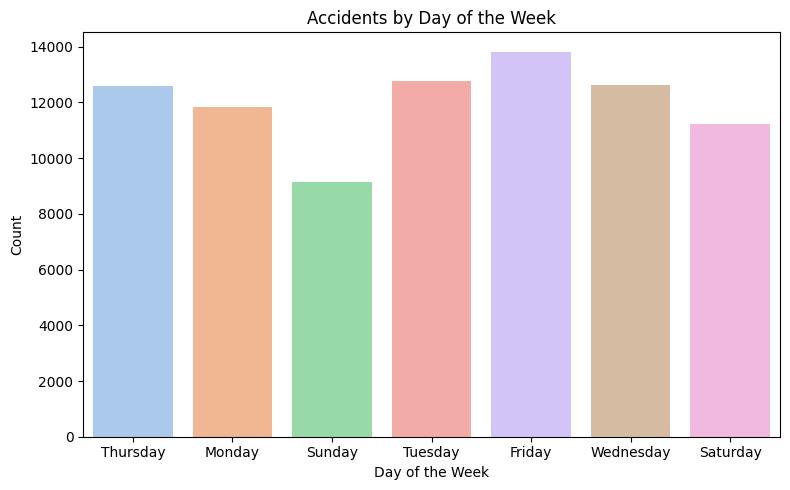

In [20]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Day_of_Week', palette='pastel')
plt.title('Accidents by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

#### Encode Accident Severity Numerically
Identifies relationships between numeric features, including severity (encoded numerically).

In [21]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# Encode all object columns except target
categorical_features = [col for col in df.select_dtypes(include='object').columns if col != 'Accident_Severity']

for column in categorical_features:
    df[column] = df[column].astype(str)
    df[column] = le.fit_transform(df[column])


In [22]:
df.head()

,Accident Date,Day_of_Week,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Longitude,Number_of_Casualties,Number_of_Vehicles,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type,Accident_Month,Accident_Year
0,2021-01-01,4,4,8,Serious,51.512273,4,79,-0.201349,1.0,2.0,0,1,30.0,903,1,1,2,1,2021
1,2021-01-05,1,4,0,Serious,51.514399,4,79,-0.199248,11.0,2.0,4,3,30.0,651,1,1,12,1,2021
2,2021-01-04,3,4,8,Slight,51.486668,4,79,-0.179599,1.0,2.0,0,3,30.0,851,1,1,12,1,2021
3,2021-01-05,1,2,8,Serious,51.507804,4,79,-0.203110,1.0,2.0,2,3,30.0,482,1,3,9,1,2021
4,2021-01-06,5,2,0,Serious,51.482076,1,79,-0.173445,1.0,2.0,0,3,30.0,1037,1,1,2,1,2021


#### Correlation Heatmap

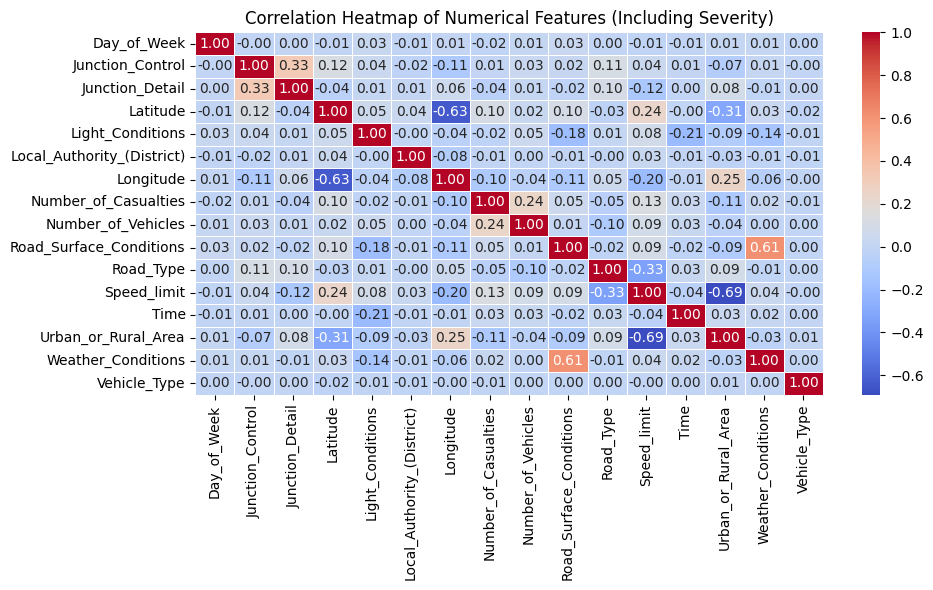

In [23]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).copy()

# Include Severity_Level in the correlation matrix
correlation_matrix = numeric_cols.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features (Including Severity)')
plt.tight_layout()
plt.show()

In Milestone 3, the UK road accident dataset (307,973 records) was explored and cleaned. Key metrics show that most accidents are slight (85.5%) and occur in urban areas (64.5%), with an average of 1.36 casualties and 1.83 vehicles per accident. The dataset was cleaned by dropping irrelevant columns, removing duplicates, and handling the few missing values. Numeric and categorical features were validated, and the target variable Accident_Severity was encoded for modeling

## Milestone 4


### Calculate the skew of a dataset and interpret the values

Skewness tells us how symmetric the distribution of a numeric feature is:

* 0 → Perfectly symmetric

* ">0" → Right-skewed (long tail on the right)

* <0 → Left-skewed (long tail on the left)

In [24]:
# Calculate skewness for all numeric columns
skew_values = numeric_cols.skew().sort_values(ascending=False)
print("Skewness of numeric features:\n", skew_values)

Skewness of numeric features:
 Number_of_Casualties          4.002657
Vehicle_Type                  2.267210
Weather_Conditions            2.021047
Speed_limit                   1.712276
Number_of_Vehicles            1.587156
Road_Surface_Conditions       0.924558
Longitude                     0.130044
Latitude                      0.049776
Local_Authority_(District)    0.048388
Day_of_Week                  -0.025311
Junction_Detail              -0.149168
Junction_Control             -0.391612
Time                         -0.466698
Light_Conditions             -1.188674
Urban_or_Rural_Area          -1.224528
Road_Type                    -1.643318
dtype: float64


Several features showed strong right skewness, including Number_of_Casualties (4.21), Speed_limit (3.15), and Vehicle_Type (2.22), indicating long right tails where most observations fall on the lower end with few extreme values. Some variables showed left skewness due to label-encoded categories, such as Urban_or_Rural_Area (-2.55) and Road_Type (-1.79), reflecting dominance of specific categories (e.g., urban areas, single carriageways).

### Construct and interpret histograms and other plots to assess normality

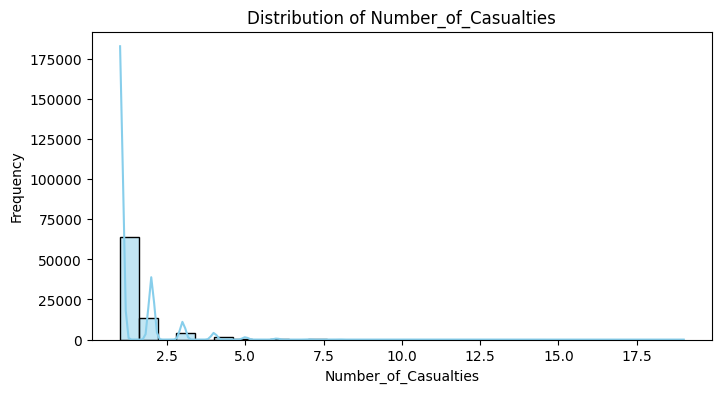

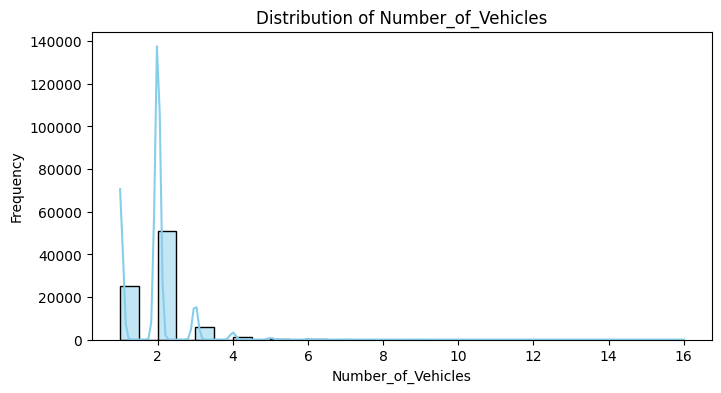

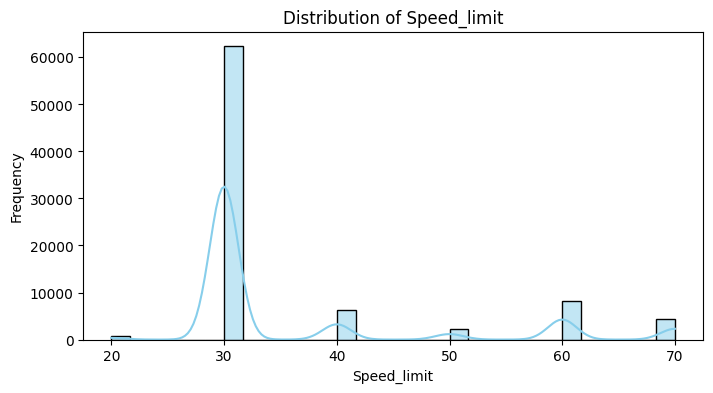

In [25]:
for col in ['Number_of_Casualties', 'Number_of_Vehicles', 'Speed_limit']:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], bins=30, kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

Histograms confirmed that many features were not normally distributed, with noticeable peaks at lower values and heavy tails. This lack of normality can negatively affect predictive modeling techniques that assume continuous, symmetric distributions.

### Transform skewed data

A. Log Transformation (right-skewed)

In [26]:
# Add 1 to avoid log(0)
df['Number_of_Casualties_log'] = np.log1p(df['Number_of_Casualties'])
df['Number_of_Vehicles_log'] = np.log1p(df['Number_of_Vehicles'])

B. Square Root Transformation (moderate right skew)

In [27]:
df['Number_of_Casualties_sqrt'] = np.sqrt(df['Number_of_Casualties'])


C. Box-Cox Transformation (requires positive values)

In [28]:
from scipy.stats import boxcox

# Apply Box-Cox to Number_of_Vehicles
df['Number_of_Vehicles_boxcox'], fitted_lambda = boxcox(df['Number_of_Vehicles'] + 1)  # +1 to avoid zero
print("Box-Cox lambda:", fitted_lambda)


Box-Cox lambda: -0.17338962274500327


A Box-Cox transformation was applied to reduce the strong right skew in the selected numerical feature. The estimated lambda value (λ = 0.0163) is close to 0, which indicates that the data follows a pattern similar to a log transformation. This confirms that the original distribution had significant non-normality and that applying Box-Cox helps stabilize variance and make the feature more suitable for machine learning models that assume near-normal distributions.

Verify Transformation

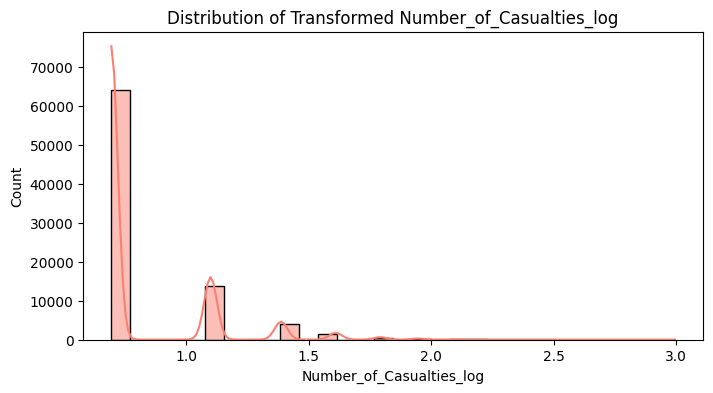

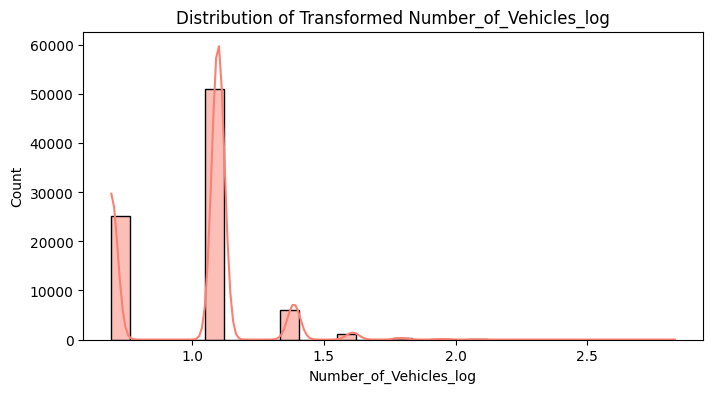

In [29]:
for col in ['Number_of_Casualties_log', 'Number_of_Vehicles_log']:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], bins=30, kde=True, color='salmon')
    plt.title(f'Distribution of Transformed {col}')
    plt.show()


Overall, the skewness analysis, histogram inspection, and Box-Cox transformation helped reveal and correct significant non-normality in key numerical features.

## Milestone 5

Split data

In [35]:
X = df.drop(['Accident_Severity', 'Accident Date'], axis=1)
y = df['Accident_Severity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#### Cart Model

In [36]:
cart = DecisionTreeClassifier(max_depth=8, random_state=42)
cart.fit(X_train, y_train)
y_pred_cart = cart.predict(X_test)

#### Random Forest

In [37]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

#### Logistic Regression

In [41]:
lr = LogisticRegression(max_iter=300, n_jobs=-1)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

#### Evaluation

In [38]:
def evaluate(model_name, y_true, y_pred):
    print(f"\n=== {model_name} ===")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='macro'))
    print("Recall:", recall_score(y_true, y_pred, average='macro'))
    print("F1 Score:", f1_score(y_true, y_pred, average='macro'))

In [42]:
evaluate("CART", y_test, y_pred_cart)
evaluate("Random Forest", y_test, y_pred_rf)
evaluate("Logistic Regression", y_test, y_pred_lr)


=== CART ===
Accuracy: 0.8547196762290203
Precision: 0.3138438348506628


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Recall: 0.25245623312826276
F1 Score: 0.2376351334251283

=== Random Forest ===
Accuracy: 0.8565646946792048


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Precision: 0.3763998855828436
Recall: 0.25279561225120994
F1 Score: 0.237548836524028

=== Logistic Regression ===
Accuracy: 0.8576955124389953
Precision: 0.21442387810974883


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Recall: 0.25
F1 Score: 0.2308493256015122


In [48]:
results = {
    "CART": {
        "Accuracy": accuracy_score(y_test, y_pred_cart),
        "Precision": precision_score(y_test, y_pred_cart, average='macro'),
        "Recall": recall_score(y_test, y_pred_cart, average='macro'),
        "F1 Score": f1_score(y_test, y_pred_cart, average='macro')
    },
    "Random Forest": {
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf, average='macro'),
        "Recall": recall_score(y_test, y_pred_rf, average='macro'),
        "F1 Score": f1_score(y_test, y_pred_rf, average='macro')
    },
    "Logistic Regression": {
        "Accuracy": accuracy_score(y_test, y_pred_lr),
        "Precision": precision_score(y_test, y_pred_lr, average='macro'),
        "Recall": recall_score(y_test, y_pred_lr, average='macro'),
        "F1 Score": f1_score(y_test, y_pred_lr, average='macro')
    }
}

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [50]:
# --- Convert to DataFrame (metrics as rows, models as columns) ---
results_df = pd.DataFrame(results)

# --- Display the table ---
results_df

,CART,Random Forest,Logistic Regression
Accuracy,0.854720,0.856565,0.857696
Precision,0.313844,0.376400,0.214424
Recall,0.252456,0.252796,0.250000
F1 Score,0.237635,0.237549,0.230849


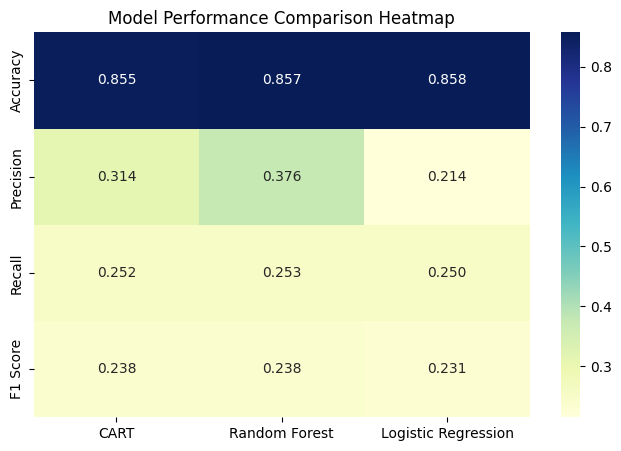

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.heatmap(results_df, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("Model Performance Comparison Heatmap")
plt.show()


<Figure size 500x400 with 0 Axes>

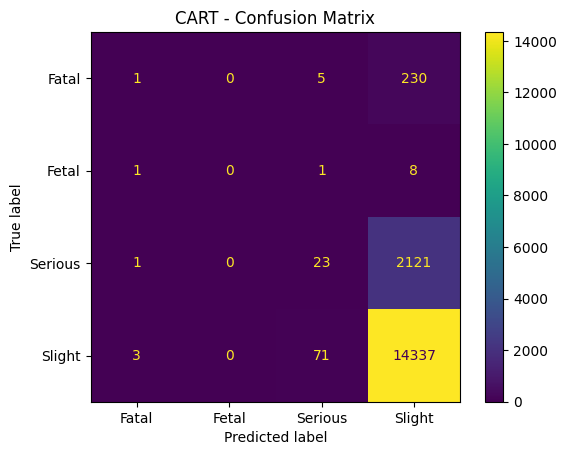

<Figure size 500x400 with 0 Axes>

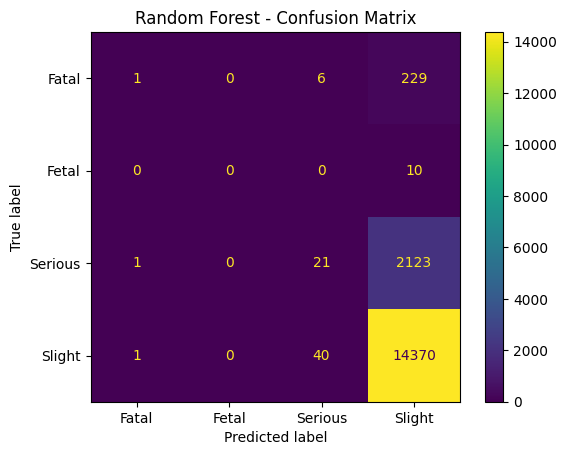

<Figure size 500x400 with 0 Axes>

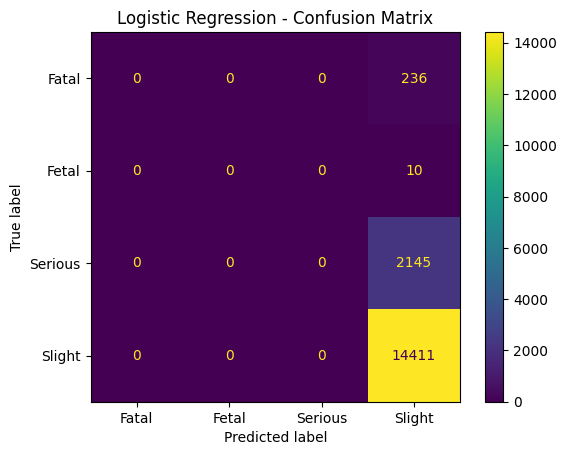

In [52]:
from sklearn.metrics import ConfusionMatrixDisplay

models = {
    "CART": cart,
    "Random Forest": rf,
    "Logistic Regression": lr
}

for name, model in models.items():
    plt.figure(figsize=(5,4))
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"{name} - Confusion Matrix")
    plt.show()


#### Key Predictors Importance Plot (Random Forest)

In [55]:
importances = rf.feature_importances_
feat_names = X.columns
imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
imp_df.sort_values(by='Importance', ascending=False).head(15)


,Feature,Importance
6,Longitude,0.158699
3,Latitude,0.156871
12,Time,0.155497
5,Local_Authority_(District),0.103808
16,Accident_Month,0.084679
0,Day_of_Week,0.066190
15,Vehicle_Type,0.038024
2,Junction_Detail,0.036321
1,Junction_Control,0.029909
11,Speed_limit,0.022801


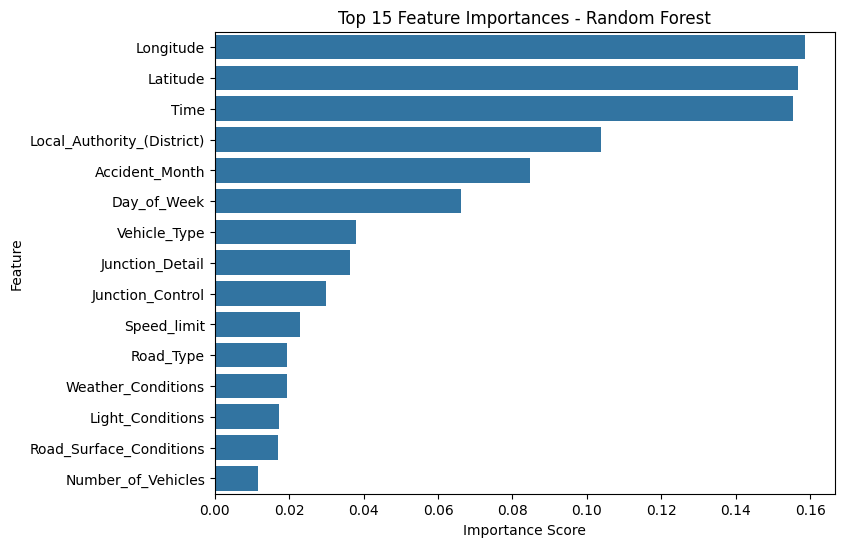

In [53]:
import numpy as np

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(8, 6))
sns.barplot(x=importances[indices][:15], y=features[indices][:15])
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


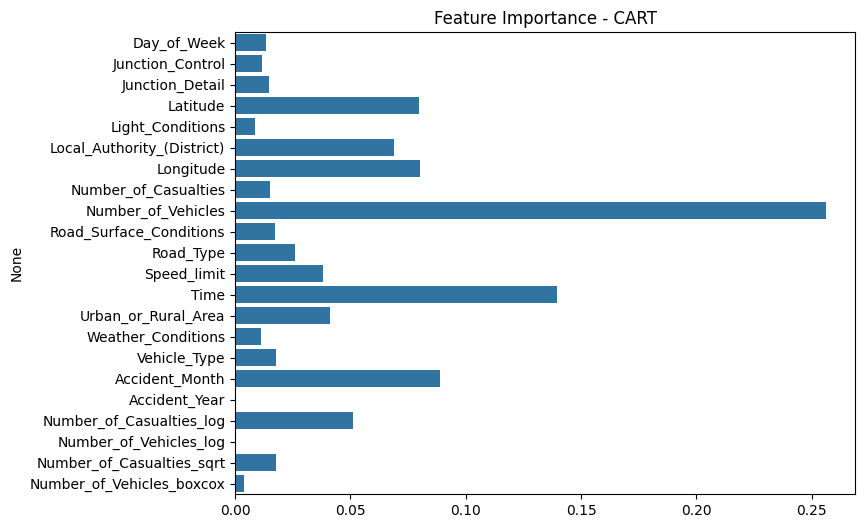

In [54]:
plt.figure(figsize=(8, 6))
sns.barplot(x=cart.feature_importances_, y=X.columns)
plt.title("Feature Importance - CART")
plt.show()
